<a href="https://colab.research.google.com/github/ditodewantoro/DATA-ANALYST/blob/main/Scraping_Detikcom_ML__14105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install googlesearch-python

In [ ]:
from googlesearch import search
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import os

In [ ]:
os.makedirs("failed_html", exist_ok=True)

query = 'mobile legend site:detik.com after:2025-04-30 before:2025-06-01'
jumlah_link = 70
hasil_scrape = []

link_berita = list(search(query, num_results=jumlah_link))

for idx, url in enumerate(link_berita):
    try:
        if any(x in url for x in ['video', 'foto']):
            print(f"[{idx+1}] Lewat (video/foto): {url}")
            continue

        res = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        soup = BeautifulSoup(res.text, 'lxml')

        title = soup.find('title').text.strip()

        content_div = (
            soup.find('div', class_='detail__body-text itp_bodycontent') or
            soup.find('div', class_='detail__body-text') or
            soup.find('div', class_='itp_bodycontent')
        )

        if content_div:
            paragraphs = content_div.find_all('p')
            content = ' '.join(p.text for p in paragraphs)
        else:
            content = '[Konten tidak ditemukan]'

            with open(f"failed_html/failed_{idx+1}.html", "w", encoding='utf-8') as f:
                f.write(soup.prettify())

        hasil_scrape.append({
            'Judul': title,
            'Link': url,
            'Isi': content
        })

        print(f"[{idx+1}] ✅ Masuk (Mei): {title[:50]}...")
        time.sleep(1)

    except Exception as e:
        print(f"[{idx+1}] ❌ Gagal: {url}")
        print(f"Error: {e}")
        continue



[1] ✅ Masuk (Mei): Game Mobile Legends Bakal Masuk Sekolah, Begini Ka...
[2] ✅ Masuk (Mei): Game Mobile Legends Bakal Masuk Kurikulum di Surab...
[3] ✅ Masuk (Mei): Mobile Legends Akan Jadi Ekstrakurikuler di Sekola...
[4] ✅ Masuk (Mei): Mobile Legends Jadi Ekstrakurikuler di Surabaya, P...
[5] ✅ Masuk (Mei): Tips Dapetin Skin Keren di Mobile Legends Tanpa To...
[6] ✅ Masuk (Mei): Skuad Timnas Mobile Legends Men Indonesia di SEA G...
[7] ✅ Masuk (Mei): Google...
[8] ✅ Masuk (Mei): Apa itu Fitur Magic Sentry di Mobile Legends, Kapa...
[9] ✅ Masuk (Mei): Game eSports Terpopuler 2025: Dari Mobile Legends ...
[10] ✅ Masuk (Mei): Ini Alasan Team Liquid ID Wakili RI di Mobile Lege...
[11] ✅ Masuk (Mei): Daftar Atlet Mobile Legends Women yang Wakili RI d...
[12] ✅ Masuk (Mei): Timnas IESF 2025 Mobile Legends Diumumkan, Full Ro...
[13] ✅ Masuk (Mei): Top Up MLBB Bisa Dapat Skin Spesial Naruto, Mau?...
[14] ✅ Masuk (Mei): Jadwal MPL ID Season 15 Pekan 7, Catat Tanggal dan...
[15] ✅ Masuk (Mei):

In [ ]:
df = pd.DataFrame(hasil_scrape)
df.to_csv("Detikcom_ML.csv", index=False, encoding='utf-8')

In [ ]:
import pandas as pd
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
# 1. Load the Data
file_path = 'Detikcom_ML.csv'  # Replace with your file path
try:
    df = pd.read_csv(file_path, encoding='utf-8')  # or use encoding='latin1' if needed
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='latin1')  #Try alternative
print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
print(df.columns)

Index(['Judul', 'Link', 'Isi'], dtype='object')


In [ ]:
print(df.head())

                                               Judul  \
0  Game Mobile Legends Bakal Masuk Sekolah, Begin...   
1  Game Mobile Legends Bakal Masuk Kurikulum di S...   
2  Mobile Legends Akan Jadi Ekstrakurikuler di Se...   
3  Mobile Legends Jadi Ekstrakurikuler di Surabay...   
4  Tips Dapetin Skin Keren di Mobile Legends Tanp...   

                                                Link  \
0  https://www.detik.com/edu/detikpedia/d-7930104...   
1  https://www.detik.com/edu/sekolah/d-7920859/ga...   
2  https://www.detik.com/jatim/berita/d-7918538/m...   
3  https://www.detik.com/edu/sekolah/d-7922829/mo...   
4  https://inet.detik.com/games-news/d-7940577/ti...   

                                                 Isi  
0  Dinas Pendidikan (Dispendik) Surabaya akan mem...  
1  Game Mobile Legends akan masuk kurikulum pelaj...  
2  Dinas Pendidikan (Dispendik) Surabaya berencan...  
3  Permainan Mobile Legends (ML) direncanakan ole...  
4  Mobile Legends: Bang Bang (MLBB) hingga kini m..

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Judul   68 non-null     object
 1   Link    68 non-null     object
 2   Isi     68 non-null     object
dtypes: object(3)
memory usage: 1.7+ KB
None


In [ ]:
import pandas as pd

# Hapus baris dengan isi konten placeholder
df = df[df['Isi'] != '[Konten tidak ditemukan]']

# (Opsional) Juga hapus yang kosong atau whitespace-only
df = df[df['Isi'].str.strip() != '']

# Reset index after dropping rows
df = df.reset_index(drop=True)

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Stopwords Indonesia + custom
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StopWordRemoverFactory()
nltk_stopwords = set(factory.get_stop_words())

custom_stopwords = {
    'ri', 'r', 'ya', 'aji', 'budi', 'gunadi', 'sadikin', 'dr', '7', '9', '53', 'kris', 'of',
    '1', 'aipki', 'te', 'jn1', 'no', 'bgs', 'sih', 'd', 'mass', 'suas', 'ct', 'yan', 'wang',
    'klaim', 'judol', 'plt', 'ke18', 'inggris', 'brasil', 'yunani', 'dk', 'nol', 'vietnam',
    'stresstres', 'v', 'spkj', 'ldl', 'pria9', 'fkrtl', 'blokir', 'url', 'nih', 'net', 'die',
    'them', 'some', 'see', 'tt', 'bor', 't', 'arssi', 'si', 'pp', 'ii', 'pa', 'dd', 'b', 'aja',
    'al', 'loh', 'bak', 'tersebut', 'banyak', 'lebih', 'guru', 'besar', 'jeansnya', 'jeans',
    'scroll','to','continue','with','content'
}

indonesian_stopwords = nltk_stopwords.union(custom_stopwords)

def clean_text(text):
    if isinstance(text, str):
        # Lowercase
        text = text.lower()

        # Remove URL, HTML tags, and numbers
        text = re.sub(r"http\S+|www\S+|<.*?>|\d+", " ", text)

        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Tokenize
        tokens = word_tokenize(text)

        # Remove stopwords and short tokens
        filtered_tokens = [token for token in tokens if token not in indonesian_stopwords and len(token) > 2]

        return ' '.join(filtered_tokens)
    else:
        return ""

df['cleaned_text'] = df['Isi'].astype(str).apply(clean_text) #important to convert to string before cleaning

print("Data cleaning and preprocessing completed.")

Data cleaning and preprocessing completed.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Judul         64 non-null     object
 1   Link          64 non-null     object
 2   Isi           64 non-null     object
 3   cleaned_text  64 non-null     object
dtypes: object(4)
memory usage: 2.1+ KB


In [ ]:
df['cleaned_text'] = df['Isi'].astype(str).apply(clean_text) #important to convert to string before cleaning

print("Data cleaning and preprocessing completed.")

Data cleaning and preprocessing completed.


In [ ]:
#Print Original and Cleaned Comments

print("\n--- First 10 Original and Cleaned Comments ---")
for i in range(min(10, len(df))):  # Print up to the first 10 comments
    print(f"Original: {df['Isi'][i]}")
    print(f"Cleaned:  {df['cleaned_text'][i]}\n")

print("Data cleaning and preprocessing completed.")


--- First 10 Original and Cleaned Comments ---
Original: Dinas Pendidikan (Dispendik) Surabaya akan memasukkan game Mobile Legends sebagai kegiatan ekstrakurikuler mulai tahun ajaran baru 2025/2026. Harapannya, ekskul ini dapat menjadi kegiatan yang edukatif sekaligus menyenangkan bagi siswa. Kabar ini disampaikan Kepala Bidang (Kabid) Guru dan Tenaga Kependidikan Dinas Pendidikan Kota Surabaya, Tri EndangKustianingsih di sela pembukaan programMLBB Teacher Ambassador di Surabaya, Kamis (15/5/2025). "Targetnya mungkin tahun ajaran baru, karena guru-guru kan sudah dilatih, supaya juga bisa membuat sebuah strategi pembelajaran yang baru. Sehingga di dalamnya juga harus tahu ada pembelajarannya edukatif, game-game edukatif seperti apa, yang nanti akan ditekankan kepada guru-guru, ke anak-anak kita," kata Tri, seperti dikutip dari laman Dinas Kominfo Provinsi Jawa Timur. 
SCROLL TO CONTINUE WITH CONTENT
 Bekerja sama dengan pengembang game Moonton Games, Pemerintah Kota Surabaya juga mengg

In [ ]:
# Apply the clean_text function to the 'Isi' column
df['cleaned_text'] = df['Isi'].apply(clean_text)

# Save original and cleaned comments to a CSV file
df[['Isi', 'cleaned_text']].to_csv("cleaned_comments.csv", index=False)

print("Cleaned comments saved successfully to cleaned_comments.csv")

Cleaned comments saved successfully to cleaned_comments.csv


In [ ]:
# 3. Exploratory Data Analysis (EDA)
def eda(df):
    """
    Performs exploratory data analysis on the cleaned comments.
    """
    # 3.1. Word Frequency Analysis:
    all_words = ' '.join(df['cleaned_text'].astype(str)).split()
    word_counts = pd.Series(all_words).value_counts().nlargest(20)  # Top 20 words

    plt.figure(figsize=(12, 6))
    sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')
    plt.title('Top 20 Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()


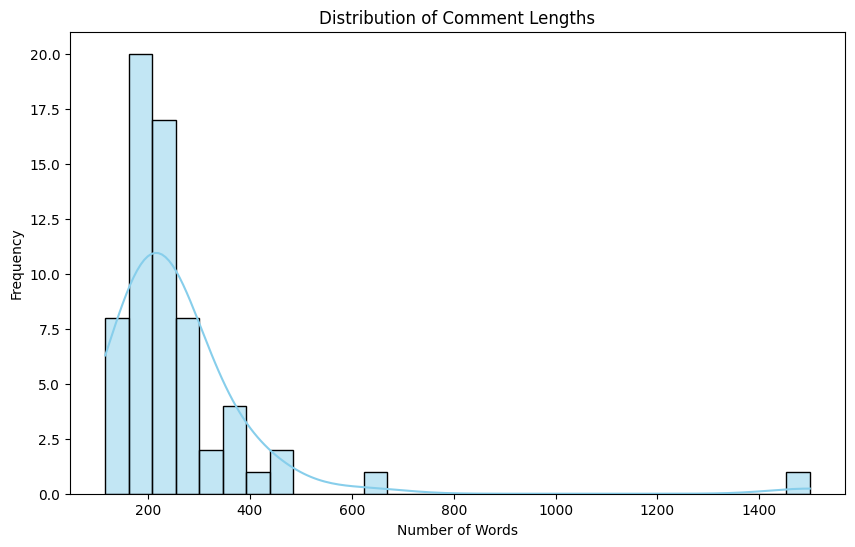

Exploratory data analysis completed.


/tmp/ipython-input-14-1034046575.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


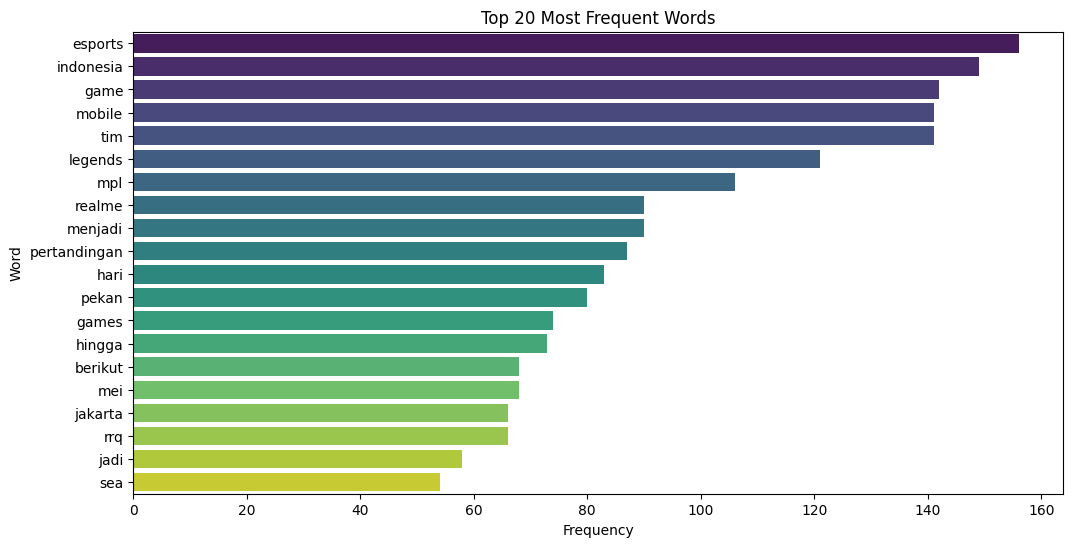

In [ ]:
# 3.2. Comment Length Distribution:
df['comment_length'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()
print("Exploratory data analysis completed.")

eda(df)


In [ ]:
from collections import Counter

# Function to count word frequency
def count_word_frequency(text_series):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts

# Get word frequency dictionary
word_freq = count_word_frequency(df['cleaned_text'])

# Convert to DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)

# Print all word frequencies
print("\nWord Frequency List:")
print(word_freq_df.to_string(index=False))  # Print entire frequency list


Word Frequency List:
                 Word  Frequency
              esports        156
            indonesia        149
                 game        142
               mobile        141
                  tim        141
              legends        121
                  mpl        106
               realme         90
              menjadi         90
         pertandingan         87
                 hari         83
                pekan         80
                games         74
               hingga         73
              berikut         68
                  mei         68
              jakarta         66
                  rrq         66
                 jadi         58
                  sea         54
               pemain         52
                 satu         51
                 team         49
                 bang         49
               timnas         48
                tahun         47
               season         46
                kedua         46
                 skin

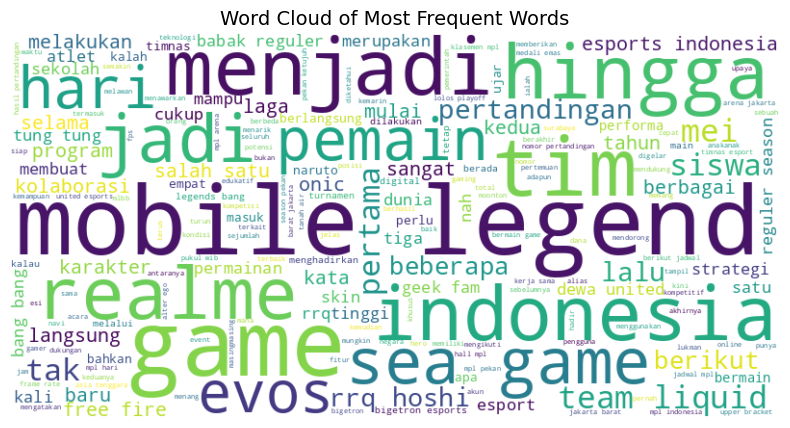

In [ ]:
# Generate Word Cloud

from wordcloud import WordCloud
def generate_wordcloud(text_series):
    text = ' '.join(text_series)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud of Most Frequent Words", fontsize=14)
    plt.show()

# Generate and display the word cloud
generate_wordcloud(df['cleaned_text'])

/tmp/ipython-input-18-3310986620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")


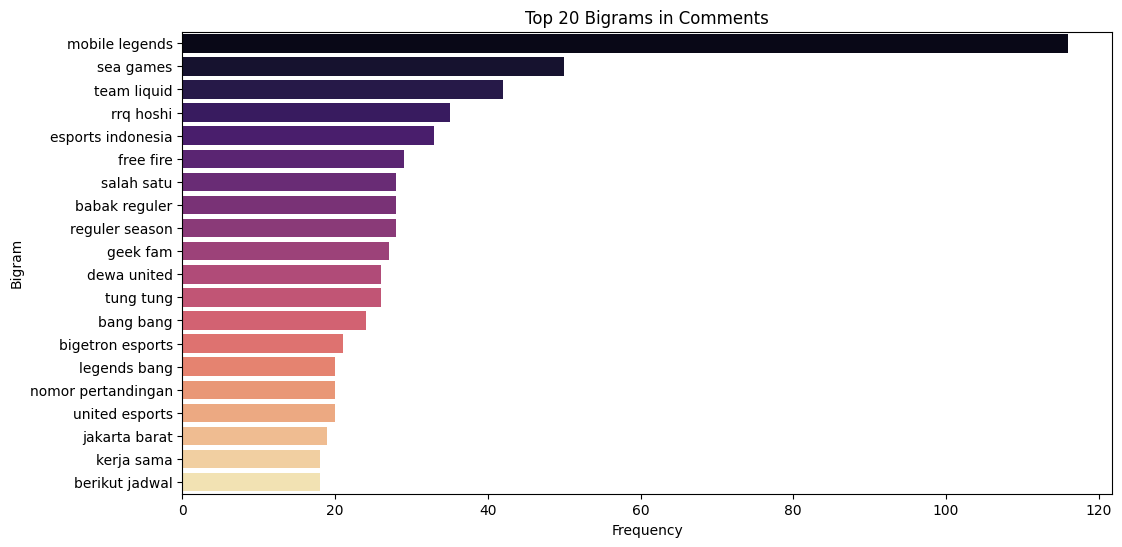

In [ ]:
# Most Frequent Word Pairs
from nltk.util import bigrams

# Generate bigrams
all_words = ' '.join(df['cleaned_text']).split()
bigrams_list = list(bigrams(all_words))

# Count most common bigrams
bigram_counts = Counter(bigrams_list)
bigram_df = pd.DataFrame(bigram_counts.most_common(20), columns=["Bigram", "Frequency"])

# Plot bigram bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=bigram_df["Frequency"], y=bigram_df["Bigram"].apply(lambda x: ' '.join(x)), palette="magma")
plt.title("Top 20 Bigrams in Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

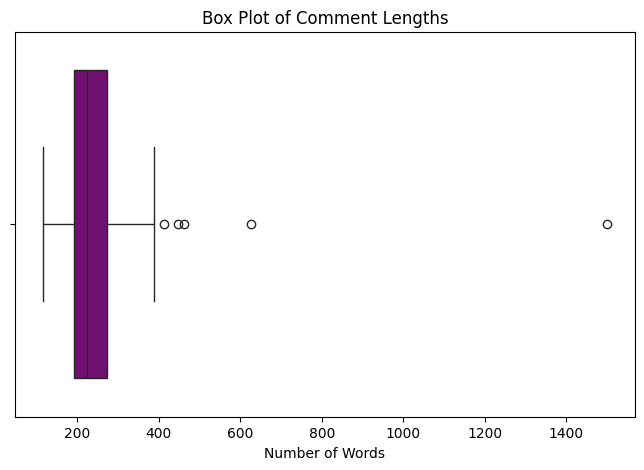

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['comment_length'], color='purple')
plt.title("Box Plot of Comment Lengths")
plt.xlabel("Number of Words")
plt.show()

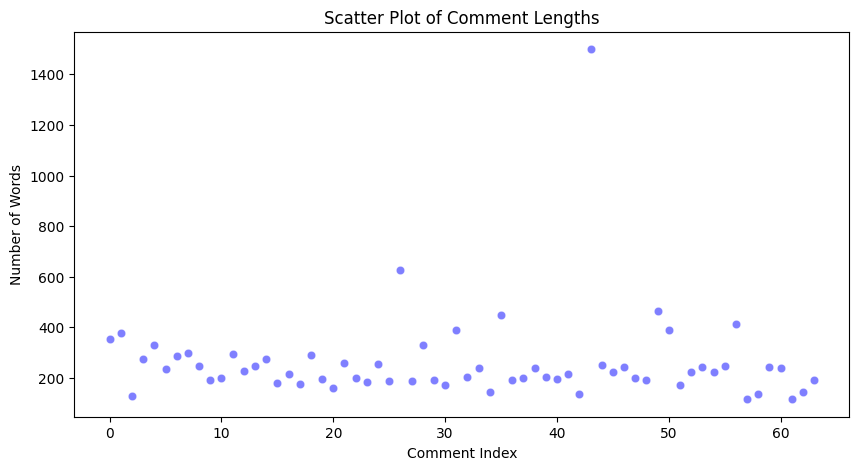

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=range(len(df)), y=df['comment_length'], alpha=0.5, color="blue")
plt.title("Scatter Plot of Comment Lengths")
plt.xlabel("Comment Index")
plt.ylabel("Number of Words")
plt.show()

/tmp/ipython-input-21-3135578455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")


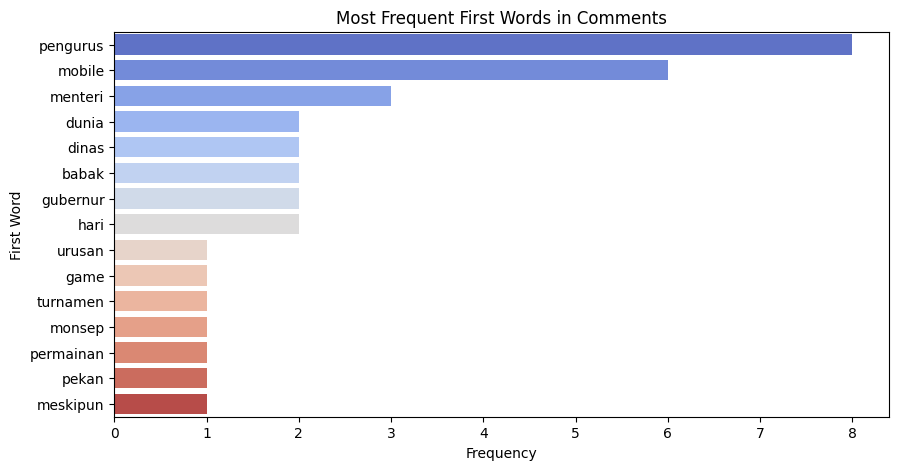

In [ ]:
first_words = df['cleaned_text'].apply(lambda x: x.split()[0] if isinstance(x, str) and x else None)
first_word_counts = first_words.value_counts().nlargest(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=first_word_counts.values, y=first_word_counts.index, palette="coolwarm")
plt.title("Most Frequent First Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("First Word")
plt.show()

In [ ]:
# Instal library utama BERTopic
!pip install bertopic

# Untuk visualisasi, instal juga paket ini
!pip install bertopic[visualization]

# Anda juga akan memerlukan sentence-transformers
!pip install sentence-transformers

# Dan pandas untuk mengelola data
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords # Import stopwords

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer


# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(n_neighbors=15, n_components=2, min_dist=0.1, metric='cosine', random_state=42)

# Step 3 - Cluster reduced embeddings
# Adjust min_cluster_size and min_samples to potentially get more topics
hdbscan_model = HDBSCAN(min_cluster_size=3, min_samples=3, metric='euclidean', cluster_selection_method='eom', prediction_data=True) # Reduced values

# Step 4 - Tokenize topics
# Get Indonesian stop words from NLTK and combine with custom stopwords
nltk_stop_words = set(stopwords.words('indonesian'))
all_stop_words = list(nltk_stop_words.union(custom_stopwords)) # Use the custom_stopwords defined earlier

vectorizer_model = CountVectorizer(stop_words=all_stop_words) # Pass the list of stop words

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
  representation_model=representation_model, # Step 6 - (Optional) Fine-tune topic representations
  calculate_probabilities=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from bertopic import BERTopic

documents = df['cleaned_text'].tolist()
topics, probs = topic_model.fit_transform(documents)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6,-1_jakarta_pengguna_pengalaman_perayaan,"[jakarta, pengguna, pengalaman, perayaan, perk...",[pengurus esports indonesia esi mengumumkan se...
1,0,15,0_jakarta_jaya_raja_menang,"[jakarta, jaya, raja, menang, esports, penggem...",[berakhir serangkai pertandingan babak reguler...
2,1,13,1_indonesia_jakarta_kartasana_komunikasi,"[indonesia, jakarta, kartasana, komunikasi, ke...",[wakil ketua dpr sufmi dasco ahmad mengetahui ...
3,2,10,2_esports_indonesia_diselenggarakan_mengirimkan,"[esports, indonesia, diselenggarakan, mengirim...",[pengurus esports indonesia esi mengumumkan se...
4,3,9,3_legends_pengembangan_mobile_pembelajaran,"[legends, pengembangan, mobile, pembelajaran, ...",[game mobile legends masuk kurikulum pelajaran...
5,4,7,4_mobapay_legends_gaming_mobile,"[mobapay, legends, gaming, mobile, moba, bater...",[mobile legends bang bang mlbb hingga kini men...
6,5,4,5_esports_jakarta_league_mpl,"[esports, jakarta, league, mpl, langsung, kana...",[mobile legends professional league mpl merupa...


In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.get_topic(0)

[('jakarta', np.float32(0.46780202)),
 ('jaya', np.float32(0.39675614)),
 ('raja', np.float32(0.3573523)),
 ('menang', np.float32(0.33438665)),
 ('esports', np.float32(0.32417774)),
 ('penggemar', np.float32(0.32027388)),
 ('pekan', np.float32(0.3162586)),
 ('kanal', np.float32(0.30682585)),
 ('dinyatakan', np.float32(0.3059101)),
 ('kedelapan', np.float32(0.30205628))]

In [ ]:
print(topic_model.get_topics())

{-1: [('jakarta', np.float32(0.4180941)), ('pengguna', np.float32(0.3822623)), ('pengalaman', np.float32(0.35832006)), ('perayaan', np.float32(0.34200686)), ('perkembangan', np.float32(0.33587903)), ('wisatawan', np.float32(0.33047637)), ('kota', np.float32(0.328839)), ('rangkaian', np.float32(0.32124949)), ('masyarakat', np.float32(0.31689632)), ('peningkatan', np.float32(0.31484964))], 0: [('jakarta', np.float32(0.46780202)), ('jaya', np.float32(0.39675614)), ('raja', np.float32(0.3573523)), ('menang', np.float32(0.33438665)), ('esports', np.float32(0.32417774)), ('penggemar', np.float32(0.32027388)), ('pekan', np.float32(0.3162586)), ('kanal', np.float32(0.30682585)), ('dinyatakan', np.float32(0.3059101)), ('kedelapan', np.float32(0.30205628))], 1: [('indonesia', np.float32(0.41589847)), ('jakarta', np.float32(0.41238737)), ('kartasana', np.float32(0.34471378)), ('komunikasi', np.float32(0.3299272)), ('kesehatan', np.float32(0.32120693)), ('pelajar', np.float32(0.3160048)), ('aplika

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Judul           64 non-null     object
 1   Link            64 non-null     object
 2   Isi             64 non-null     object
 3   cleaned_text    64 non-null     object
 4   comment_length  64 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 2.6+ KB


In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_distribution(probs[1])

In [ ]:
topic_model.visualize_hierarchy()

**LDA**

In [ ]:
!pip install pyldavis

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade gensim --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.3.1 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.3.1 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.1 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.1 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 148.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 129.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1
  Attempting uninstall: smart-open
    Found existing installation: smart_open 7.3.0
    Uninstalling smart_open-7.3.0:
      Successfully unins

In [ ]:
import gensim
from gensim.utils import simple_preprocess

def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=False))


In [ ]:
# Ensure data_tokens is defined
try:
    data_tokens
except NameError:
    # Load the data if df is not defined
    try:
        df
    except NameError:
        file_path = 'cleaned_comments.csv'
        import pandas as pd # Import pandas here
        try:
            df = pd.read_csv(file_path, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding='latin1')

    import gensim # Import gensim here
    from gensim.utils import simple_preprocess

    def sent_to_words(sentences):
        for sentence in sentences:
            yield(gensim.utils.simple_preprocess(str(sentence), deacc=False))

    word_tokens = df['cleaned_text'].dropna().values.tolist()
    data_tokens = list(sent_to_words(word_tokens))


bigram = gensim.models.Phrases(data_tokens, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_tokens], threshold=100)

In [ ]:
bigram = gensim.models.Phrases(data_tokens, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_tokens], threshold=100)

In [ ]:
for index in range(len(data_tokens)):
  for token in bigram[data_tokens[index]]:
    if '_' in token:
      data_tokens[index].append(token)
  for token in trigram[data_tokens[index]]:
    if '_' in token:
      data_tokens[index].append(token)

In [ ]:
from gensim import corpora, models

# create dictionary
dictionary = corpora.Dictionary(data_tokens)

# create corpus
corpus = [dictionary.doc2bow(token) for token in data_tokens]

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
from numpy import array

def get_coherence_values(dictionary, corpus, tokens, num_topics):
  model_list = []
  coherence_values = []
  for i in range(1, num_topics+1):
    model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=i, iterations=100, random_state=2021)
    coherence_model = CoherenceModel(model=model, texts=tokens,
                                     dictionary=dictionary, coherence='c_v')
    model_list.append(model)
    coherence_values.append(coherence_model.get_coherence())

  return model_list, coherence_values

In [ ]:
num_topics = 10
model_list, coherence_values = get_coherence_values(dictionary, corpus,
                                                    data_tokens, num_topics)

In [ ]:
coherence_df = pd.DataFrame(list(zip([i+1 for i in range(num_topics)], coherence_values)),
                            columns=['num_of_topics', 'coherence_values'])
coherence_df

,num_of_topics,coherence_values
0,1,0.261527
1,2,0.300027
2,3,0.337159
3,4,0.364570
4,5,0.387944
5,6,0.413607
6,7,0.416483
7,8,0.428317
8,9,0.411938
9,10,0.434743


In [ ]:
# build LDA Model
model = LdaModel(corpus=corpus, num_topics=9, id2word=dictionary)

In [ ]:
for index, topic in model.print_topics(-1):
  print('Topic {}:\nWord: {}\n'.format(index+1, topic))

Topic 1:
Word: 0.012*"mobile_legends" + 0.009*"esports" + 0.006*"tim" + 0.005*"sea_games" + 0.005*"rrq_hoshi" + 0.005*"team_liquid" + 0.005*"tung_tung" + 0.005*"mobile" + 0.005*"game" + 0.004*"tung"

Topic 2:
Word: 0.012*"mobile_legends" + 0.007*"sea_games" + 0.006*"mobile" + 0.005*"ubpp_antam" + 0.005*"dewa_united" + 0.004*"indonesia" + 0.004*"tim" + 0.004*"legends" + 0.004*"game" + 0.004*"pertandingan"

Topic 3:
Word: 0.015*"mobile_legends" + 0.007*"game" + 0.007*"mobile" + 0.006*"legends" + 0.005*"realme" + 0.004*"bang_bang" + 0.004*"asia_tenggara" + 0.004*"menjadi" + 0.003*"mlbb" + 0.003*"siswa"

Topic 4:
Word: 0.014*"mobile_legends" + 0.009*"mpl" + 0.008*"indonesia" + 0.007*"tim" + 0.007*"kerja_sama" + 0.006*"esports" + 0.006*"pertandingan" + 0.005*"legends" + 0.005*"team_liquid" + 0.005*"pekan"

Topic 5:
Word: 0.017*"mobile_legends" + 0.007*"mobile" + 0.007*"game" + 0.007*"magic_sentry" + 0.007*"tim" + 0.007*"esports" + 0.006*"legends" + 0.005*"mpl" + 0.005*"dewa_united" + 0.005*

In [ ]:
def format_topics_sentences(ldamodel=None, corpus=None, texts=None):
    rows = []

    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)

        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                rows.append([
                    int(topic_num),
                    round(prop_topic, 4),
                    topic_keywords,
                    " ".join(texts[i])
                ])
            else:
                break

    sent_topics_df = pd.DataFrame(rows, columns=[
        'Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords', 'Text'
    ])
    return sent_topics_df

In [ ]:
df_topic_sents_keywords = format_topics_sentences(ldamodel=model,
                                                  corpus=corpus,
                                                  texts=data_tokens)

df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic',
                             'Topic_Perc_Contrib', 'Keywords', 'Text']

In [ ]:
df_dominant_topic[:20:]

,Document_No,Dominant_Topic,Topic_Perc_Contrib,Keywords,Text
0,0,7,0.7996,"mobile_legends, indonesia, sea_games, mobile, ...",dinas pendidikan dispendik surabaya memasukkan...
1,1,2,0.8311,"mobile_legends, game, mobile, legends, realme,...",game mobile legends masuk kurikulum pelajaran ...
2,2,5,0.9936,"mobile_legends, game, salah_satu, menjadi, leg...",dinas pendidikan dispendik surabaya berencana ...
3,3,4,0.5220,"mobile_legends, mobile, game, magic_sentry, ti...",permainan mobile legends direncanakan dinas pe...
4,4,5,0.9977,"mobile_legends, game, salah_satu, menjadi, leg...",mobile legends bang bang mlbb hingga kini menj...
5,5,7,0.9960,"mobile_legends, indonesia, sea_games, mobile, ...",pengurus esports indonesia esi mengumumkan sku...
6,6,4,0.9972,"mobile_legends, mobile, game, magic_sentry, ti...",mobile legends meluncurkan fitur menarik diber...
7,7,5,0.9972,"mobile_legends, game, salah_satu, menjadi, leg...",dunia esports terus mengalami perkembangan pes...
8,8,7,0.5880,"mobile_legends, indonesia, sea_games, mobile, ...",pengurus esports indonesia esi mengungkapkan a...
9,9,7,0.9963,"mobile_legends, indonesia, sea_games, mobile, ...",pengurus esports indonesia esi resmi mengumumk...


In [ ]:
import pyLDAvis.gensim

topic_data = pyLDAvis.gensim.prepare(model, corpus=corpus, dictionary=dictionary, mds='pcoa')
pyLDAvis.display(topic_data)